<a href="https://colab.research.google.com/github/lanaajs/Processamento-de-Linguagem-Natural-Python/blob/Aulas/05_Aula.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install --upgrade gensim

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from sklearn.decomposition import PCA

plt.style.use('ggplot')

In [ ]:
frases_treino = [
    # Contexto de Backend
    ["o", "desenvolvedor", "backend", "programa", "em", "python"],
    ["o", "desenvolvedor", "backend", "programa", "em", "java"],
    ["o", "engenheiro", "backend", "escreve", "api", "em", "python"],
    ["a", "api", "backend", "foi", "feita", "em", "java"],

    # Contexto de Frontend
    ["o", "desenvolvedor", "frontend", "programa", "em", "javascript"],
    ["o", "desenvolvedor", "frontend", "cria", "telas", "em", "react"],
    ["a", "interface", "frontend", "foi", "feita", "em", "javascript"],
    ["o", "engenheiro", "frontend", "escreve", "componentes", "em", "react"],

    # Contexto de Problemas/Bugs
    ["encontrei", "um", "bug", "critico", "no", "codigo", "fonte"],
    ["descobri", "um", "erro", "critico", "no", "codigo", "fonte"],
    ["o", "sistema", "apresentou", "uma", "falha", "no", "servidor"],
    ["ocorreu", "um", "bug", "grave", "no", "servidor", "de", "producao"],
    ["o", "erro", "grave", "derrubou", "o", "servidor", "de", "producao"]
]

print(f"Total de frases para treinamento: {len(frases_treino)}")

Total de frases para treinamento: 13


In [ ]:
modelo_w2 = Word2Vec(sentences=frases_treino,
                     vector_size=10,
                     window=2,
                     min_count=1,
                     workers=1,
                     epochs=100)

In [ ]:
vetor_bug = modelo_w2.wv['bug']
print(f"\nVetor denso da palavra 'bug'- com 10 dimensões: \n{vetor_bug}")


Vetor denso da palavra 'bug'- com 10 dimensões: 
[-0.08337694  0.03229833 -0.04024711 -0.0630494   0.04914214  0.05959085
  0.1190094  -0.0365344   0.05523566  0.06173742]


In [ ]:
print("Palavras mais similares a 'erro' semanticamente: ")

for palavra, similaridade in modelo_w2.wv.most_similar('erro', topn=3):
  print(f"- {palavra}: {similaridade}")

Palavras mais similares a 'erro' semanticamente: 
- fonte: 0.520375669002533
- servidor: 0.5164678692817688
- feita: 0.5076484680175781


In [ ]:
print("Palavras mais similares a 'java' semanticamente: ")

for palavra, similaridade in modelo_w2.wv.most_similar('java', topn=5):
  print(f"- {palavra}: {similaridade}")

Palavras mais similares a 'java' semanticamente: 
- escreve: 0.5992681980133057
- componentes: 0.4081973731517792
- em: 0.38927894830703735
- feita: 0.38145026564598083
- servidor: 0.28826579451560974


#### PCA - Aplicando a dimensionalidade em 2D

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [ ]:
palavras = list(modelo_w2.wv.index_to_key)
vetores = modelo_w2.wv[palavras]

In [ ]:
pca = PCA(n_components=2)
coordenadas_2d = pca.fit_transform(vetores)

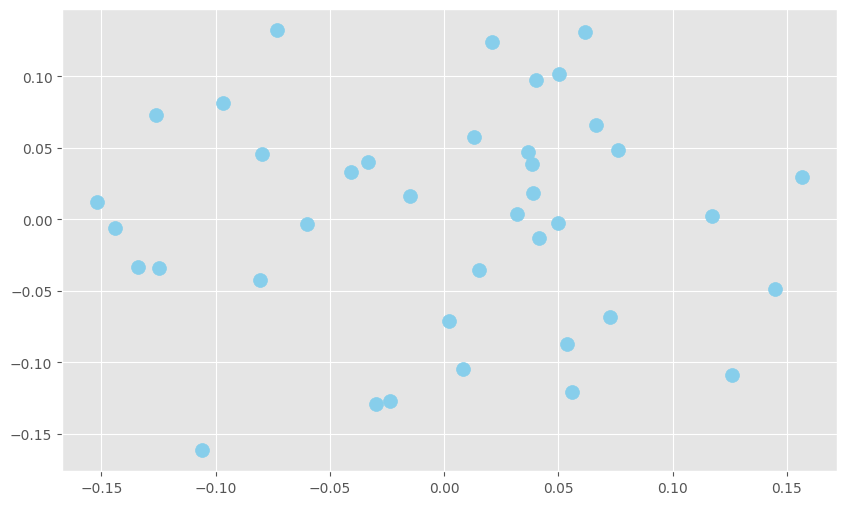

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(coordenadas_2d[:, 0], coordenadas_2d[:, 1], c="skyblue", s=100)

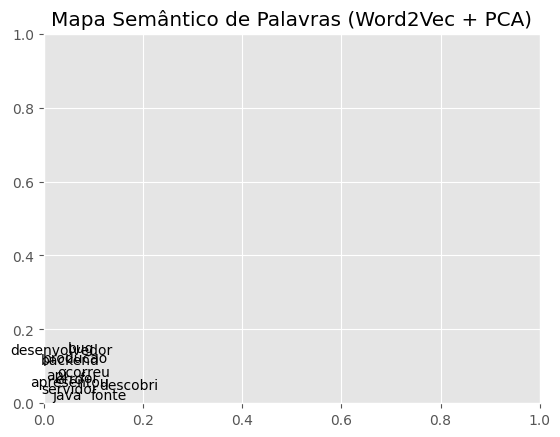

In [ ]:
for i, palavra in enumerate(palavras):
  plt.annotate(palavra, (coordenadas_2d[i, 0], coordenadas_2d[i, 1]), textcoords="offset points", xytext=(5, 2), ha="center")

plt.title("Mapa Semântico de Palavras (Word2Vec + PCA)")
plt.show()